PyTorch Version: 2.11.0+cu128
CUDA Available: True

Baixando o dataset (pode levar alguns minutos na primeira vez)...

Tamanho do dataset completo: 3680 imagens.


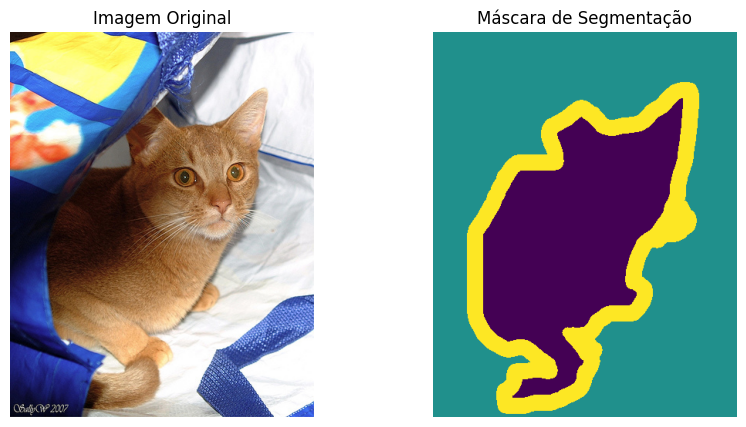

In [ ]:
!pip install torchmetrics

import torch
import torchvision
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

print("\nBaixando o dataset (pode levar alguns minutos na primeira vez)...")
dataset_completo = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    download=True
)

print(f"\nTamanho do dataset completo: {len(dataset_completo)} imagens.")

imagem, mascara = dataset_completo[0]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagem)
ax[0].set_title("Imagem Original")
ax[0].axis('off')

mascara_np = np.array(mascara) - 1
ax[1].imshow(mascara_np, cmap='viridis')
ax[1].set_title("Máscara de Segmentação")
ax[1].axis('off')

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import numpy as np

class PetDataset(Dataset):
    def __init__(self, subset, img_size=128):
        self.subset = subset

        self.img_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.mask_transform = T.Compose([
            T.Resize((img_size, img_size), interpolation=T.InterpolationMode.NEAREST)
        ])

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, mask = self.subset[idx]
        img = self.img_transform(img)
        mask = self.mask_transform(mask)

        mask = torch.as_tensor(np.array(mask), dtype=torch.long) - 1
        return img, mask

treino_dataset = PetDataset(dataset_completo, img_size=128)
treino_loader = DataLoader(treino_dataset, batch_size=32, shuffle=True)
print("DataLoader criado com sucesso! Lotes prontos para a GPU.")

class DoubleConv(nn.Module):
    """Bloco auxiliar com duas convoluções seguidas de ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNetTransferMobileNetV2(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()

        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features

        self.encoder0 = mobilenet[0]
        self.encoder1 = mobilenet[1:3]
        self.encoder2 = mobilenet[3:7]
        self.encoder3 = mobilenet[7:14]
        self.encoder4 = mobilenet[14:18]

        for param in self.parameters():
            param.requires_grad = False

        self.up_conv1 = DoubleConv(320 + 96, 128)
        self.up_conv2 = DoubleConv(128 + 32, 64)
        self.up_conv3 = DoubleConv(64 + 24, 32)
        self.up_conv4 = DoubleConv(32 + 32, 16)

        self.out = nn.Conv2d(16, n_classes, kernel_size=1)

    def forward(self, x):
        tamanho_original = x.shape[2:]

        x0 = self.encoder0(x)
        x1 = self.encoder1(x0)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)

        x_up = F.interpolate(x4, scale_factor=2.0, mode='bilinear', align_corners=True)
        x_up = torch.cat([x3, x_up], dim=1)
        x_up = self.up_conv1(x_up)

        x_up = F.interpolate(x_up, scale_factor=2.0, mode='bilinear', align_corners=True)
        x_up = torch.cat([x2, x_up], dim=1)
        x_up = self.up_conv2(x_up)

        x_up = F.interpolate(x_up, scale_factor=2.0, mode='bilinear', align_corners=True)
        x_up = torch.cat([x1, x_up], dim=1)
        x_up = self.up_conv3(x_up)

        x_up = F.interpolate(x_up, scale_factor=2.0, mode='bilinear', align_corners=True)
        x_up = torch.cat([x0, x_up], dim=1)
        x_up = self.up_conv4(x_up)

        saida_64 = self.out(x_up)

        saida_128 = F.interpolate(saida_64, size=tamanho_original, mode='bilinear', align_corners=True)

        return saida_128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

modelo = UNetTransferMobileNetV2(n_classes=3).to(device)
print(f"Modelo UNetTransferMobileNetV2 instanciado e alocado em: {device}")

DataLoader criado com sucesso! Lotes prontos para a GPU.
Modelo UNetTransferMobileNetV2 instanciado e alocado em: cuda


In [ ]:
import torch.optim as optim
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassAccuracy
import torch.nn as nn
import torch

epochs = 25
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)

iou_metric = MulticlassJaccardIndex(num_classes=3).to(device)
acc_metric = MulticlassAccuracy(num_classes=3, average='macro').to(device)

print("Iniciando o treinamento do modelo...\n")

for epoch in range(epochs):
    modelo.train()
    loss_epoch = 0.0

    iou_metric.reset()
    acc_metric.reset()

    for imgs, masks in treino_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = modelo(imgs)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()
        preds = torch.argmax(outputs, dim=1)

        iou_metric.update(preds, masks)
        acc_metric.update(preds, masks)

    epoch_iou = iou_metric.compute()
    epoch_acc = acc_metric.compute()

    print(f"Época [{epoch+1}/{epochs}] | Loss: {loss_epoch/len(treino_loader):.4f} | IoU: {epoch_iou:.4f} | Acurácia: {epoch_acc:.4f}")

print("\nTreinamento finalizado com sucesso!")

Iniciando o treinamento do modelo...

Época [1/25] | Loss: 0.4004 | IoU: 0.6018 | Acurácia: 0.7032
Época [2/25] | Loss: 0.2647 | IoU: 0.7147 | Acurácia: 0.8061
Época [3/25] | Loss: 0.2385 | IoU: 0.7338 | Acurácia: 0.8210
Época [4/25] | Loss: 0.2230 | IoU: 0.7465 | Acurácia: 0.8312
Época [5/25] | Loss: 0.2052 | IoU: 0.7590 | Acurácia: 0.8410
Época [6/25] | Loss: 0.1987 | IoU: 0.7636 | Acurácia: 0.8449
Época [7/25] | Loss: 0.1828 | IoU: 0.7759 | Acurácia: 0.8545
Época [8/25] | Loss: 0.1772 | IoU: 0.7800 | Acurácia: 0.8575
Época [9/25] | Loss: 0.1702 | IoU: 0.7867 | Acurácia: 0.8631
Época [10/25] | Loss: 0.1629 | IoU: 0.7923 | Acurácia: 0.8673
Época [11/25] | Loss: 0.1595 | IoU: 0.7956 | Acurácia: 0.8699
Época [12/25] | Loss: 0.1571 | IoU: 0.7983 | Acurácia: 0.8720
Época [13/25] | Loss: 0.1613 | IoU: 0.7959 | Acurácia: 0.8706
Época [14/25] | Loss: 0.1548 | IoU: 0.8010 | Acurácia: 0.8742
Época [15/25] | Loss: 0.1464 | IoU: 0.8081 | Acurácia: 0.8796
Época [16/25] | Loss: 0.1430 | IoU: 0.811

In [ ]:
!pip install litert-torch

import torch
import litert_torch

modelo.eval()
modelo.cpu()
dummy_input = torch.randn(1, 3, 128, 128)

print("\n1. Iniciando a conversão direta PyTorch -> TFLite via LiteRT (Isso pode levar de 1 a 2 minutos)...")

edge_model = litert_torch.convert(modelo, (dummy_input,))

tflite_path = "model.tflite"
edge_model.export(tflite_path)

print(f"2. SUCESSO! O arquivo '{tflite_path}' foi gerado usando a nova infraestrutura do Google.")


1. Iniciando a conversão direta PyTorch -> TFLite via LiteRT (Isso pode levar de 1 a 2 minutos)...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:21) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:21) [ DONE] LiteRT-Torch Convert (+00:21)

(00:00) [START] Write Model to model.tflite

(00:00) [ DONE] Write Model to model.tflite (+00:00)

2. SUCESSO! O arquivo 'model.tflite' foi gerado usando a nova infraestrutura do Google.
